In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [2]:
# Load dataset
boston = fetch_openml(name="boston", version=1, as_frame=True)

X = boston.data
y = boston.target.astype(float)


In [3]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [4]:
# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [5]:
# Build ANN model
model = Sequential()


In [6]:
# Input + Hidden layers
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Output layer
model.add(Dense(1))


In [8]:
# Compile model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


In [9]:
# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)


Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 595.7146 - mae: 22.4852 - val_loss: 568.7656 - val_mae: 22.2864
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 548.4547 - mae: 21.3358 - val_loss: 491.0341 - val_mae: 20.4431
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 437.3810 - mae: 18.4071 - val_loss: 321.8361 - val_mae: 16.0531
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 235.6096 - mae: 12.9129 - val_loss: 97.4786 - val_mae: 8.0713
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 81.1788 - mae: 7.1679 - val_loss: 35.4375 - val_mae: 4.2252
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 40.4607 - mae: 4.9480 - val_loss: 31.4910 - val_mae: 3.7629
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 27.7678 - mae: 3.9725 - val_loss: 29.9378 - val_mae: 3.6984
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 23.1675 - mae: 3.5726 - val_loss: 30.6129 - val_mae: 3.8212
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━

In [10]:
# Evaluate model
test_loss, test_mae = model.evaluate(X_test, y_test)

print("Test MAE:", test_mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 12.5268 - mae: 2.2464
Test MAE: 2.246386766433716


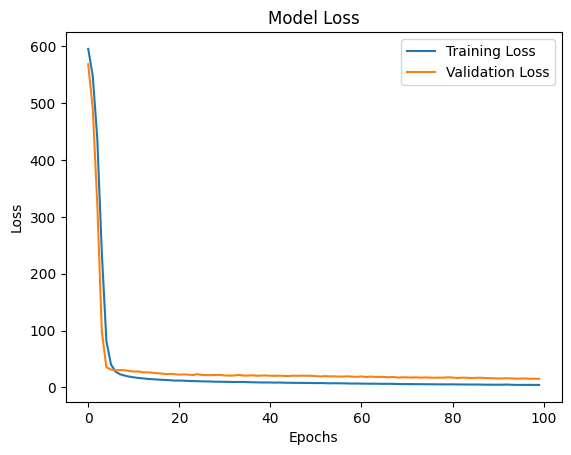

In [11]:
# Simple visual plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()